In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv(r"C:\Users\SALMAN PC\Downloads\archive\HousingData.csv")

In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [4]:
df["CRIM"].fillna(df["CRIM"].mean(),inplace=True)
df["INDUS"].fillna(df["INDUS"].mean(),inplace=True)
df["ZN"].fillna(df["ZN"].mean(),inplace=True)
df["CHAS"].fillna(df["CHAS"].mean(),inplace=True)
df["AGE"].fillna(df["AGE"].mean(),inplace=True)
df["LSTAT"].fillna(df["LSTAT"].mean(),inplace=True)

C:\Users\SALMAN PC\AppData\Local\Temp\ipykernel_6536\2932117292.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CRIM"].fillna(df["CRIM"].mean(),inplace=True)
C:\Users\SALMAN PC\AppData\Local\Temp\ipykernel_6536\2932117292.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [5]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [6]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.545770,22.921051,6.699165,0.250233,0.115878,0.702617,27.439466,2.105710,8.707259,168.537116,2.164946,91.294864,7.012739,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083235,0.000000,5.190000,0.000000,0.449000,5.885500,45.925000,2.100175,4.000000,279.000000,17.400000,375.377500,7.230000,17.025000
50%,0.290250,0.000000,9.900000,0.000000,0.538000,6.208500,74.450000,3.207450,5.000000,330.000000,19.050000,391.440000,11.995000,21.200000
75%,3.611874,11.211934,18.100000,0.000000,0.624000,6.623500,93.575000,5.188425,24.000000,666.000000,20.200000,396.225000,16.570000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


AttributeError: module 'matplotlib.pyplot' has no attribute 'gride'

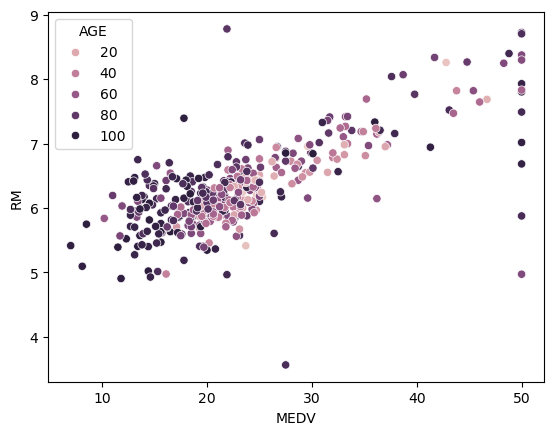

In [36]:
sns.scatterplot(data=df,x="MEDV",y="RM",hue="AGE")
plt.gride

In [8]:
q1=df["CRIM"].quantile(0.25)
q3=df["CRIM"].quantile(0.75)
IQR=q3-q1
q3

np.float64(3.6118739711934156)

In [9]:
max_range=q3+(1.5*IQR)
min_range=q1-(1.5*IQR)

In [10]:
min_range,max_range

(np.float64(-5.2097234567901225), np.float64(8.90483242798354))

<Axes: xlabel='CRIM'>

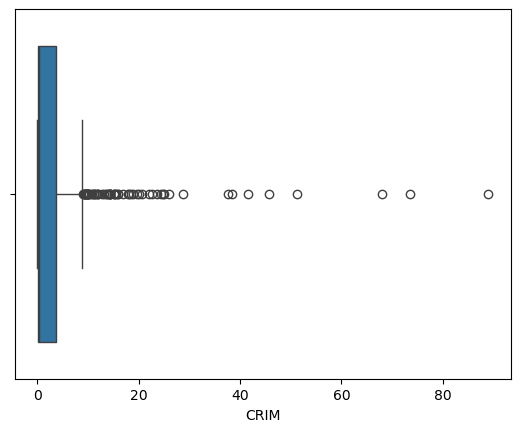

In [11]:
sns.boxplot(x="CRIM",data=df)

In [12]:
df=df[df["CRIM"]<=max_range]

In [13]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.200000,4.0900,1,296,15.3,396.90,4.980000,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.900000,4.9671,2,242,17.8,396.90,9.140000,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.100000,4.9671,2,242,17.8,392.83,4.030000,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.800000,6.0622,3,222,18.7,394.63,2.940000,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.200000,6.0622,3,222,18.7,396.90,12.715432,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.100000,2.4786,1,273,21.0,391.99,12.715432,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.700000,2.2875,1,273,21.0,396.90,9.080000,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.000000,2.1675,1,273,21.0,396.90,5.640000,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.300000,2.3889,1,273,21.0,393.45,6.480000,22.0


In [14]:
df.shape

(442, 14)

<Axes: xlabel='CRIM'>

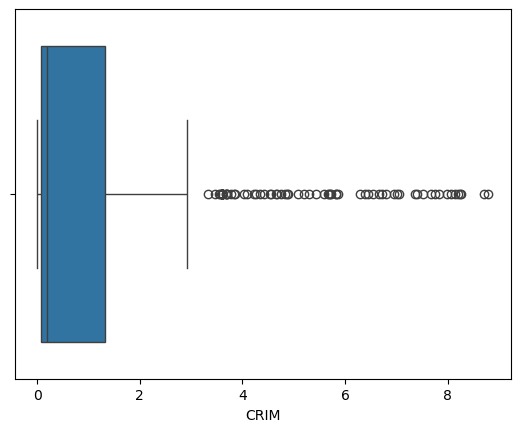

In [15]:
sns.boxplot(x="CRIM",data=df)

In [16]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,1.261307,12.784649,10.083972,0.077035,0.536425,6.345654,64.785185,4.092274,7.457014,370.914027,18.202941,369.882647,11.358341,23.933032
std,2.066991,24.113632,6.584639,0.262771,0.111428,0.672419,27.222806,2.087614,7.219852,146.589518,2.204904,68.069555,5.916107,8.668385
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,7.000000
25%,0.070543,0.000000,4.930000,0.000000,0.445500,5.924500,41.600000,2.402200,4.000000,276.000000,16.600000,378.082500,6.720000,18.800000
50%,0.197295,0.000000,8.140000,0.000000,0.515000,6.227500,68.518519,3.651900,5.000000,307.000000,18.600000,392.190000,10.450000,22.000000
75%,1.325495,20.000000,18.100000,0.000000,0.585000,6.640250,89.975000,5.415900,6.000000,403.000000,20.200000,396.120000,14.697500,26.925000
max,8.792120,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,34.410000,50.000000


In [17]:
q1=df["ZN"].quantile(0.25)
q3=df["ZN"].quantile(0.75)
IQR=q3-q1
q3,q1

(np.float64(20.0), np.float64(0.0))

In [18]:
max_range=q3+(1.5*IQR)
min_range=q1-(1.5*IQR)

In [19]:
min_range,max_range

(np.float64(-30.0), np.float64(50.0))

In [20]:
df=df[df["ZN"]<=max_range]

In [21]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,1.379208,5.699283,10.861150,0.082863,0.550330,6.299847,68.553304,3.730587,7.909548,378.095477,18.393719,367.770302,11.957857,23.298995
std,2.131742,11.014270,6.447299,0.271834,0.108648,0.665790,25.726830,1.792546,7.455112,151.366208,2.137641,71.317830,5.872868,8.423447
min,0.006320,0.000000,1.250000,0.000000,0.409000,3.561000,2.900000,1.129600,1.000000,188.000000,13.000000,0.320000,1.730000,7.000000
25%,0.094115,0.000000,5.860000,0.000000,0.464000,5.895750,50.175000,2.317750,4.000000,277.000000,17.400000,377.522500,7.402500,18.425000
50%,0.250895,0.000000,9.125000,0.000000,0.524000,6.167000,73.000000,3.361800,5.000000,307.000000,18.700000,391.880000,11.430000,21.700000
75%,1.624685,8.408951,18.100000,0.000000,0.605000,6.566000,91.375000,4.721100,7.000000,428.000000,20.200000,396.060000,15.320000,25.000000
max,8.792120,45.000000,27.740000,1.000000,0.871000,8.780000,100.000000,10.585700,24.000000,711.000000,22.000000,396.900000,34.410000,50.000000


In [22]:
df.shape

(398, 14)

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
x=df.drop("MEDV",axis=1)
y=df["MEDV"]

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [26]:
scaler=StandardScaler()

In [27]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [28]:
model=LinearRegression()

In [29]:
model.fit(x_train,y_train)

LinearRegression()

In [30]:
y_pred=model.predict(x_test)

In [31]:
y_pred

array([24.36508688, 26.73306731, 14.17934013, 32.91422953, 26.62601125,
       27.57720465, 27.87640322, 18.67447801, 23.90518715, 12.64561941,
       18.88635412, 14.47183969, 24.0778645 , 28.98930632, 14.08639   ,
       23.16570452, 16.12564878, 26.89158408, 25.54291152, 23.10004402,
       28.25775173, 19.89112245, 19.29165063, 37.38538781, 30.29135554,
       22.49899012, 18.97751216, 44.76236023, 24.22719303, 20.38796893,
       22.87403292, 21.1546139 , 22.71655713, 23.66818628, 24.48520843,
       18.81588569, 20.97353553, 28.9347296 , 38.00640102, 15.01475209,
       17.89589421, 17.72472362, 25.32637897, 13.09915596, 27.31311666,
       12.08815051, 12.0140011 , 32.15143615, 16.53988215, 35.65631799,
        8.5259467 , 23.11250013, 18.5436811 , 21.64235366, 14.13983793,
       29.45631293, 22.15588623, 21.13383848, 11.64457196, 32.02313452,
       20.46953656, 34.89902114, 25.57126721, 22.36081003, 20.06292503,
       18.31559104, 28.81937949, 25.24899748, 26.46452556, 26.91

In [32]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 13.442091174658355
R2 Score: 0.7770551615616257
